<a href="https://colab.research.google.com/github/pronabpaul/SSL_Collapse_ACR_Analysis/blob/main/Representation_Collapse_SSL_ACR_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Is Effective Rank a Reliable Predictor of Transfer Performance in Self-Supervised Medical Foundation Models?



## Abstract

Self-supervised learning (SSL) has advanced medical image analysis, yet models often fail under domain shift across hospitals, scanners, or patient populations. This failure is often attributed to **representation collapse**, features concentrating in a low-dimensional subspace. Does collapse predict transfer failure, and can Adaptive Collapse Recovery (ACR), a geometry-aware regularisation, mitigate it? Three architectures (supervised ResNet-50, DINOv2, MAE) are evaluated on a diabetic retinopathy grading task (RetinaMNIST source, IDRiD target). Collapse is quantified using effective rank, participation ratio, spectral decay, and Neural Anisotropy Directions (NAD). This study examines collapse severity across models, the correlation between geometric metrics and transfer performance, and the efficacy of ACR. The goal is to determine if representation geometry can serve as a reliable predictor of transferability and whether ACR can recover lost representational capacity, offering insight into the causal role of representation geometry in clinical transferability and a practical method to enhance foundation model robustness.


**Keywords:** Representation collapse, effective rank, Adaptive Collapse Recovery (ACR), self-supervised learning, transfer learning, medical imaging


## 1. Introduction

Self-supervised learning (SSL) models often fail when deployed under domain shift, for example across different hospitals or imaging devices. One explanation is **dimensional collapse**: features become confined to a low-rank subspace, reducing adaptability (Jing et al., 2022; Hua et al., 2021). If collapse causes transfer failure, then models with higher effective rank should transfer better.

To test this prediction, three architectures (supervised ResNet-50, DINOv2, MAE) are evaluated on a diabetic retinopathy grading task (RetinaMNIST source, IDRiD target), along with Adaptive Collapse Recovery (ACR), a regularisation method that adjusts a covariance penalty based on the measured effective rank.

Does higher effective rank ensure better transfer? Can ACR mitigate collapse? The following sections address these questions.



## 2. Methods

### 2.1 Models

Three representative architectures were selected to cover distinct learning paradigms: supervised pretraining, self-distillation, and masked autoencoding. ResNet-50 (supervised on ImageNet) serves as a traditional baseline. DINOv2 (self-distilled ViT) represents state-of-the-art SSL that produces highly separable features. MAE (masked autoencoder) represents reconstruction-based SSL, which learns different inductive biases. This selection allows comparison of how different pretraining objectives influence dimensional collapse and transferability.

| Model | Learning Paradigm | Feature Dim | Notes |
|-------|------------------|-------------|-------|
| ResNet-50 | Supervised ImageNet | 2048 | Supervised baseline. |
| DINOv2 | Self-distillation | 384 | Self-distilled ViT. |
| MAE | Masked autoencoder | 768 | Masked autoencoder. |


### 2.2 Datasets

Two publicly available diabetic retinopathy (DR) grading datasets were used to evaluate transfer performance. Both share the same 5-class severity scale (0-4), enabling direct comparison.

- **Source:** RetinaMNIST (MedMNIST) - a collection of retinal fundus photographs (derived from the DeepDRiD dataset). It provides a clean, and widely used benchmark for DR grading. Stratified split: 864 train, 216 validation, 400 test.
- **Target:** IDRiD (IEEE DataPort) - a fundus photography dataset collected in India. It represents a different population, camera system, and acquisition protocol, making it suitable as an out-of-distribution target. Stratified split: 273 train, 91 validation, 91 test.

Both datasets were resized to 224x224, normalised using ImageNet statistics (mean = [0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225]), and kept as RGB.


### 2.3 Measuring Collapse (Geometric Metrics)

Four metrics were computed on test set features:

- **Effective rank**: entropy of singular value spectrum.
- **Participation ratio**: alternative dimensionality measure.
- **Spectral decay slope**: eigenvalue concentration (more negative = more collapse).
- **NAD (Neural Anisotropy Directions)**: average cosine similarity of class means (higher = more class-space collapse).

### 2.4 Adaptive Collapse Recovery (ACR)

ACR adds a covariance penalty during fine-tuning. The total loss is defined as:

$$
L_{\text{total}} = L_{\text{task}} + \lambda L_{\text{cov}}, \qquad
L_{\text{cov}} = \frac{1}{D}\sum_{i \neq j} C_{ij}^2
$$

Three fine-tuning strategies were compared:

- **Standard**: no regularisation.
- **Fixed λ**: constant regularisation strength, λ = 10⁻⁴.
- **Adaptive ACR**: λ is updated at the end of each epoch based on the current effective rank. The update rule is:

$$
\lambda(t+1) = \lambda_0 \left[ 1 + \gamma \cdot \max\!\left(0, \frac{r_{\text{target}} - r_{\text{current}}}{r_{\text{target}}}\right) \right],
$$

where $\lambda_0 = 10^{-4}$ is the base strength, $\gamma = 0.1$ controls the adaptation rate, and $r_{\text{target}} = 0.8 \times D$ (80% of the maximum possible rank). The current effective rank $r_{\text{current}}$ is computed on a subset of 500 training samples at the end of each epoch, and an exponential moving average (decay 0.95) is applied to smooth fluctuations.

## 3. Experiments and Results

The following cells implement the experimental pipeline, from data loading to fine-tuning with ACR.

In [ ]:
from google.colab import drive
from datetime import datetime
import os
import json

# Mount Google Drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("Drive already mounted.")

# Project directory and subdirectories
PROJECT_DIR = '/content/drive/MyDrive/project3_ssl_collapse'
SUBDIRS = ["data", "features", "checkpoints", "metrics", "figures", "logs", "configs", "exports"]

for sub in SUBDIRS:
    os.makedirs(os.path.join(PROJECT_DIR, sub), exist_ok=True)

# Unique run identifier
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

# Experiment configuration
CONFIG = {
    "project_name": "Project3_SSL_Collapse",
    "run_id": RUN_ID,
    "seed": 42,
    "image_size": 224,
    "batch_size": 64,
    "description": "Measuring dimensional collapse in SSL medical models with ACR (RetinaMNIST -> IDRiD transfer)"
}

# Save config
config_path = os.path.join(PROJECT_DIR, "configs", f"config_{RUN_ID}.json")
with open(config_path, "w") as f:
    json.dump(CONFIG, f, indent=4)

print(f"Project directory: {PROJECT_DIR}")
print(f"Run ID: {RUN_ID}")
print(f"Config saved: {config_path}")
print("Subdirectories created:", SUBDIRS)

Drive already mounted.
Project directory: /content/drive/MyDrive/project3_ssl_collapse
Run ID: 20260614_121855
Config saved: /content/drive/MyDrive/project3_ssl_collapse/configs/config_20260614_121855.json
Subdirectories created: ['data', 'features', 'checkpoints', 'metrics', 'figures', 'logs', 'configs', 'exports']


In [ ]:
import sys
import subprocess
import importlib
import os
import json
import random
import numpy as np
import torch

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

def install_if_missing(package_name, import_name=None):
    if import_name is None:
        import_name = package_name.split('==')[0]
    try:
        importlib.import_module(import_name)
        print(f"[OK] {package_name} already installed")
    except ImportError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

packages = {
    "timm==0.9.2": "timm",
    "transformers==4.36.0": "transformers",
    "medmnist==2.2.0": "medmnist",
    "scikit-learn==1.3.2": "sklearn",
    "seaborn==0.13.0": "seaborn",
    "pandas==2.1.3": "pandas",
    "tqdm==4.66.1": "tqdm",
    "matplotlib==3.8.2": "matplotlib",
    "psutil==5.9.6": "psutil",
    "kagglehub==0.1.6": "kagglehub"
}

for pkg, imp in packages.items():
    install_if_missing(pkg, imp)

# Verify critical imports
try:
    import torch
    import timm
    import transformers
    import medmnist
    import sklearn
    import seaborn
    import pandas as pd
    import tqdm
    import matplotlib.pyplot as plt
    import psutil
    import kagglehub
    print("\nAll required packages imported successfully.")
except ImportError as e:
    print(f"Import error: {e}")
    sys.exit(1)

# Load run config
PROJECT_DIR = '/content/drive/MyDrive/project3_ssl_collapse'
os.makedirs(os.path.join(PROJECT_DIR, 'logs'), exist_ok=True)
config_dir = os.path.join(PROJECT_DIR, 'configs')
config_files = [f for f in os.listdir(config_dir) if f.endswith('.json')]
if not config_files:
    raise FileNotFoundError("No config file found. Run Cell 1 first.")
latest_config = sorted(config_files)[-1]
config_path = os.path.join(config_dir, latest_config)
with open(config_path, 'r') as f:
    config = json.load(f)
RUN_ID = config['run_id']

# Log environment details
env_info = {
    "run_id": RUN_ID,
    "seed": SEED,
    "deterministic_cudnn": True,
    "python_version": sys.version,
    "torch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda if torch.cuda.is_available() else None,
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None",
    "ram_gb": psutil.virtual_memory().total / 1e9
}
env_log_path = os.path.join(PROJECT_DIR, 'logs', f'environment_{RUN_ID}.txt')
with open(env_log_path, 'w') as f:
    for key, value in env_info.items():
        f.write(f"{key}: {value}\n")
print(f"\nEnvironment info saved to: {env_log_path}")

# Export requirements
!pip freeze > /content/requirements.txt
import shutil
shutil.copy('/content/requirements.txt', os.path.join(PROJECT_DIR, 'exports', 'requirements.txt'))
print("requirements.txt saved to exports/")

# Summary
print("\n" + "="*50)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")
print(f"RAM: {env_info['ram_gb']:.1f} GB")
print(f"Seed set: {SEED}")
print(f"Deterministic mode: ON")
print("="*50)

[OK] timm==0.9.2 already installed
[OK] transformers==4.36.0 already installed
Installing medmnist==2.2.0...
[OK] scikit-learn==1.3.2 already installed
[OK] seaborn==0.13.0 already installed
[OK] pandas==2.1.3 already installed
[OK] tqdm==4.66.1 already installed
[OK] matplotlib==3.8.2 already installed
[OK] psutil==5.9.6 already installed
[OK] kagglehub==0.1.6 already installed

All required packages imported successfully.

Environment info saved to: /content/drive/MyDrive/project3_ssl_collapse/logs/environment_20260614_121855.txt
requirements.txt saved to exports/

PyTorch version: 2.11.0+cpu
CUDA available: False
RAM: 13.6 GB
Seed set: 42
Deterministic mode: ON


100%|██████████| 3.29M/3.29M [00:00<00:00, 4.34MB/s]


RetinaMNIST train class distribution: {1: 102, 2: 165, 4: 53, 0: 389, 3: 155}
RetinaMNIST val class distribution: {2: 41, 0: 97, 1: 26, 3: 39, 4: 13}
RetinaMNIST test class distribution: {2: 92, 1: 46, 0: 174, 3: 68, 4: 20}
Using Colab cache for faster access to the 'idrid-dataset' dataset.
IDRiD downloaded to: /kaggle/input/idrid-dataset
Images: /kaggle/input/idrid-dataset/Imagenes/Imagenes
Labels: /kaggle/input/idrid-dataset/idrid_labels.csv
CSV columns: ['id_code', 'diagnosis', 'Risk of macular edema ', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']
ID column: 'id_code', grade column: 'diagnosis'
Loaded 455 images
IDRiD class distribution: {3: 84, 2: 156, 4: 64, 1: 22, 0: 129}
IDRiD splits: train 273, val 91, test 91
Metadata saved.


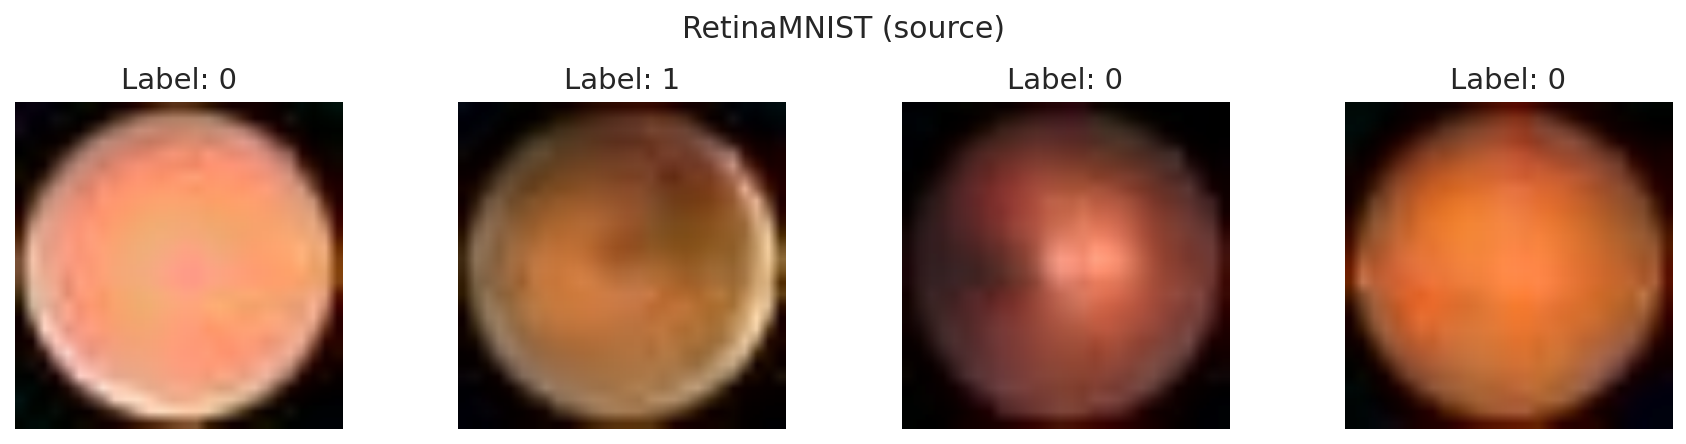

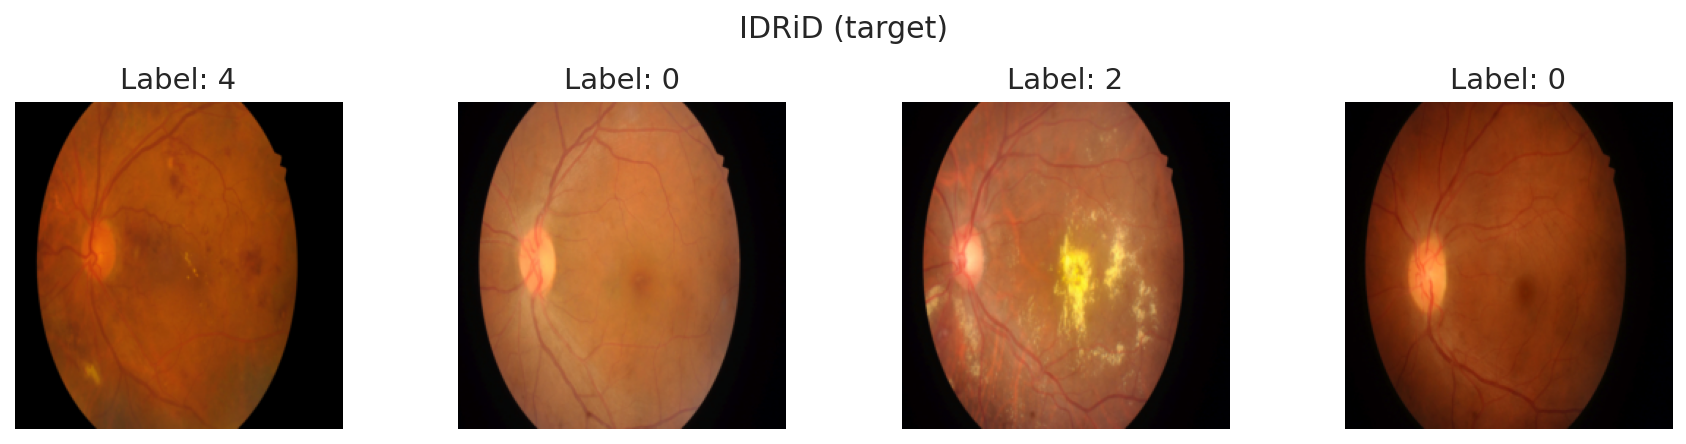


DATASET SUMMARY
Source: RetinaMNIST, 864 train, 216 val, 400 test, 5 classes
Target: IDRiD, 273 train, 91 val, 91 test, 5 classes
Image size: 224x224, batch size: 64, seed: 42


In [ ]:
import os
import random
import json
from collections import Counter
import torch
import numpy as np
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, Subset
from medmnist import RetinaMNIST
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Setup directories and reproducibility
PROJECT_DIR = '/content/drive/MyDrive/project3_ssl_collapse'
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
os.makedirs(DATA_DIR, exist_ok=True)
os.environ['MEDMNIST_CACHE'] = DATA_DIR

SEED = 42
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# Image transforms: resize to 224x224, normalize with ImageNet stats
transform_rgb = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Source: RetinaMNIST (5-class diabetic retinopathy grading)
source_full = RetinaMNIST(split='train', transform=transform_rgb, download=True)
source_test = RetinaMNIST(split='test', transform=transform_rgb, download=True)

# Stratified 80/20 train/val split on source
labels_source = np.array(source_full.labels).flatten()
indices = np.arange(len(source_full))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=SEED, stratify=labels_source)
source_train = Subset(source_full, train_idx)
source_val   = Subset(source_full, val_idx)

def log_class_distribution(dataset, name):
    if hasattr(dataset, 'indices'):
        labels = dataset.dataset.labels.flatten()[dataset.indices]
    else:
        labels = dataset.labels.flatten()
    counter = {int(k): int(v) for k, v in Counter(labels).items()}
    print(f"{name} class distribution: {counter}")
    return counter

source_train_dist = log_class_distribution(source_train, "RetinaMNIST train")
source_val_dist   = log_class_distribution(source_val,   "RetinaMNIST val")
source_test_dist  = log_class_distribution(source_test,  "RetinaMNIST test")
source_num_classes = len(np.unique(labels_source))

# Target: IDRiD (downloaded from Kaggle using kagglehub)
def download_idrid():
    try:
        import kagglehub
    except ImportError:
        raise ImportError("kagglehub not installed. Run: !pip install kagglehub")
    path = kagglehub.dataset_download("mariaherrerot/idrid-dataset")
    print(f"IDRiD downloaded to: {path}")
    return path

class IDRiDDataset(Dataset):
    def __init__(self, root, transform=None):
        self.transform = transform
        self.root = root

        # Find image folder (nested Imagenes/Imagenes)
        img_folder = None
        for item in os.listdir(root):
            if os.path.isdir(os.path.join(root, item)) and 'imagenes' in item.lower():
                first = os.path.join(root, item)
                for sub in os.listdir(first):
                    sub_path = os.path.join(first, sub)
                    if os.path.isdir(sub_path) and ('imagenes' in sub.lower() or 'image' in sub.lower()):
                        if any(f.lower().endswith('.jpg') for f in os.listdir(sub_path)):
                            img_folder = sub_path
                            break
                if img_folder:
                    break
        if img_folder is None:
            for dirpath, _, filenames in os.walk(root):
                if any(f.lower().endswith('.jpg') for f in filenames):
                    img_folder = dirpath
                    break
        if img_folder is None:
            raise FileNotFoundError(f"Could not find image folder in {root}")

        # Find CSV with labels
        csv_file = None
        for item in os.listdir(root):
            if item.endswith('.csv') and 'labels' in item.lower():
                csv_file = os.path.join(root, item)
                break
        if csv_file is None:
            raise FileNotFoundError(f"Could not find labels CSV in {root}")

        print(f"Images: {img_folder}")
        print(f"Labels: {csv_file}")

        df = pd.read_csv(csv_file)
        print(f"CSV columns: {df.columns.tolist()}")

        # Identify ID column (usually 'id_code')
        id_col = None
        for col in df.columns:
            if col.lower() in ['id_code', 'id', 'image_id', 'image', 'name', 'filename']:
                id_col = col
                break
        if id_col is None:
            id_col = df.columns[0]
            print(f"Using first column '{id_col}' as image ID")

        # Identify DR grade column (usually 'diagnosis')
        grade_col = None
        for col in df.columns:
            if col.lower() in ['diagnosis', 'grade', 'retinopathy grade', 'dr_grade', 'level']:
                grade_col = col
                break
        if grade_col is None:
            for col in df.columns:
                if df[col].dropna().isin([0,1,2,3,4]).all():
                    grade_col = col
                    break
        if grade_col is None:
            raise KeyError(f"No DR grade column. Columns: {df.columns.tolist()}")

        print(f"ID column: '{id_col}', grade column: '{grade_col}'")

        self.image_paths = []
        self.labels = []
        for _, row in df.iterrows():
            img_id = str(row[id_col]).strip()
            found = False
            for ext in ['.jpg', '.jpeg', '.png']:
                path = os.path.join(img_folder, f"{img_id}{ext}")
                if os.path.exists(path):
                    self.image_paths.append(path)
                    found = True
                    break
            if not found:
                print(f"Warning: image '{img_id}' not found")
                continue

            raw_label = row[grade_col]
            try:
                label = int(float(raw_label))
            except (ValueError, TypeError):
                mapping = {'No_DR':0, 'Mild':1, 'Moderate':2, 'Severe':3, 'Proliferative_DR':4}
                label = mapping.get(str(raw_label), None)
                if label is None:
                    raise ValueError(f"Unknown label: {raw_label}")
            if label not in range(5):
                raise ValueError(f"Label {label} out of range (0-4)")
            self.labels.append(label)

        if not self.image_paths:
            raise RuntimeError("No valid images found")

        print(f"Loaded {len(self.image_paths)} images")
        counter = {int(k): int(v) for k, v in Counter(self.labels).items()}
        print(f"IDRiD class distribution: {counter}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.transform:
            img = self.transform(img)
        return img, label

# Load IDRiD and create stratified 60/20/20 splits
try:
    idrid_root = download_idrid()
    idrid_full = IDRiDDataset(idrid_root, transform=transform_rgb)
    labels_idrid = idrid_full.labels
    indices_full = np.arange(len(idrid_full))

    train_idx, temp_idx = train_test_split(indices_full, test_size=0.4, random_state=SEED, stratify=labels_idrid)
    temp_labels = np.array(idrid_full.labels)[temp_idx]
    val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=SEED, stratify=temp_labels)

    target_train = Subset(idrid_full, train_idx)
    target_val   = Subset(idrid_full, val_idx)
    target_test  = Subset(idrid_full, test_idx)

    idrid_available = True
    target_num_classes = len(np.unique(idrid_full.labels))
    print(f"IDRiD splits: train {len(target_train)}, val {len(target_val)}, test {len(target_test)}")
except Exception as e:
    print(f"IDRiD loading failed: {e}")
    idrid_available = False
    target_train = target_val = target_test = None
    target_num_classes = None

# Dataloaders
batch_size = 64
num_workers = min(4, os.cpu_count())
pin_memory = torch.cuda.is_available()

source_train_loader = DataLoader(source_train, batch_size=batch_size, shuffle=True,
                                 num_workers=num_workers, pin_memory=pin_memory,
                                 worker_init_fn=seed_worker, generator=g)
source_val_loader   = DataLoader(source_val,   batch_size=batch_size, shuffle=False,
                                 num_workers=num_workers, pin_memory=pin_memory)
source_test_loader  = DataLoader(source_test,  batch_size=batch_size, shuffle=False,
                                 num_workers=num_workers, pin_memory=pin_memory)

if idrid_available:
    target_train_loader = DataLoader(target_train, batch_size=batch_size, shuffle=True,
                                     num_workers=num_workers, pin_memory=pin_memory,
                                     worker_init_fn=seed_worker, generator=g)
    target_val_loader   = DataLoader(target_val,   batch_size=batch_size, shuffle=False,
                                     num_workers=num_workers, pin_memory=pin_memory)
    target_test_loader  = DataLoader(target_test,  batch_size=batch_size, shuffle=False,
                                     num_workers=num_workers, pin_memory=pin_memory)
else:
    target_train_loader = target_val_loader = target_test_loader = None

# Save dataset metadata
os.makedirs(os.path.join(PROJECT_DIR, 'metrics'), exist_ok=True)
metadata = {
    "source": "RetinaMNIST",
    "target": "IDRiD" if idrid_available else "not loaded",
    "task": "5‑class DR grading",
    "source_classes": source_num_classes,
    "target_classes": target_num_classes if idrid_available else None,
    "source_train_size": len(source_train),
    "source_val_size": len(source_val),
    "source_test_size": len(source_test),
    "target_train_size": len(target_train) if idrid_available else 0,
    "target_val_size": len(target_val) if idrid_available else 0,
    "target_test_size": len(target_test) if idrid_available else 0,
    "image_size": (224,224),
    "seed": SEED,
    "splits": "source stratified 80/20, IDRiD stratified 60/20/20"
}
with open(os.path.join(PROJECT_DIR, 'metrics', 'dataset_info.json'), 'w') as f:
    json.dump(metadata, f, indent=4)
print("Metadata saved.")

# Quick visualisation of samples
def show_samples(loader, title, num_samples=4):
    if loader is None:
        return
    try:
        images, labels = next(iter(loader))
    except StopIteration:
        return
    images = images.cpu()
    fig, axes = plt.subplots(1, num_samples, figsize=(12,3))
    for i in range(num_samples):
        img = images[i].permute(1,2,0).numpy()
        mean = np.array([0.485,0.456,0.406])
        std  = np.array([0.229,0.224,0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(f"Label: {int(labels[i])}")
        axes[i].axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    os.makedirs(os.path.join(PROJECT_DIR, 'figures'), exist_ok=True)
    plt.savefig(os.path.join(PROJECT_DIR, 'figures', f"{title.replace(' ','_')}.png"))
    plt.show()

show_samples(source_train_loader, "RetinaMNIST (source)")
if idrid_available:
    show_samples(target_train_loader, "IDRiD (target)")

# Final summary
print("\n" + "="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"Source: RetinaMNIST, {len(source_train)} train, {len(source_val)} val, {len(source_test)} test, {source_num_classes} classes")
if idrid_available:
    print(f"Target: IDRiD, {len(target_train)} train, {len(target_val)} val, {len(target_test)} test, {target_num_classes} classes")
else:
    print("Target: IDRiD not loaded")
print(f"Image size: 224x224, batch size: {batch_size}, seed: {SEED}")
print("="*60)

In [ ]:
import torch
import numpy as np
from sklearn.linear_model import LinearRegression

def effective_rank(features):
    if features.shape[0] < 2:
        return 0.0
    features = features - features.mean(dim=0, keepdim=True)
    s = torch.linalg.svdvals(features)
    s2 = s ** 2
    p = s2 / (s2.sum() + 1e-8)
    entropy = -(p * torch.log(p + 1e-8)).sum()
    return torch.exp(entropy).item()

def participation_ratio(features):
    if features.shape[0] < 2:
        return 0.0
    features = features - features.mean(dim=0, keepdim=True)
    s = torch.linalg.svdvals(features)
    s2 = s ** 2
    denom = (s2 ** 2).sum()
    if denom < 1e-12:
        return 0.0
    return (s2.sum() ** 2 / denom).item()

def spectral_decay_slope(features, max_dims=50):
    """
    Compute slope of log(eigenvalue) vs log(index) using the top 'max_dims' eigenvalues.
    More negative slope = faster decay = more collapse.
    """
    if features.shape[0] < 2:
        return 0.0
    features = features - features.mean(dim=0, keepdim=True)
    C = features.T @ features / (features.shape[0] - 1)
    eigvals = torch.linalg.eigvalsh(C).flip(0)
    # Keep only the largest `max_dims` eigenvalues, clamp to avoid zeros/inf
    eigvals = eigvals[:max_dims]
    eigvals = torch.clamp(eigvals, min=1e-12)
    if len(eigvals) < 2:
        return 0.0
    eigvals = eigvals.cpu().numpy()
    indices = np.arange(1, len(eigvals) + 1)
    log_i = np.log(indices)
    log_eig = np.log(eigvals)
    reg = LinearRegression().fit(log_i.reshape(-1, 1), log_eig)
    return reg.coef_[0]

def nad_anisotropy(features, labels, num_classes, class_weighted=True):
    """
    Compute average cosine similarity between class means.
    Features are centred to remove global bias.
    Higher values indicate stronger class-space collapse.
    """
    if not torch.is_tensor(features):
        features = torch.tensor(features)
    if not torch.is_tensor(labels):
        labels = torch.tensor(labels)
    device = features.device
    labels = labels.to(device)

    # Center features globally
    features = features - features.mean(dim=0, keepdim=True)

    class_means = []
    class_weights = []
    for c in range(num_classes):
        mask = (labels == c)
        if mask.sum() > 0:
            class_means.append(features[mask].mean(dim=0))
            class_weights.append(mask.sum().item())
    if len(class_means) < 2:
        return 0.0

    means = torch.stack(class_means)
    means = means / (means.norm(dim=1, keepdim=True) + 1e-8)
    sim = means @ means.T
    eye_mask = ~torch.eye(len(means), device=device, dtype=torch.bool)
    if class_weighted:
        weights = torch.tensor(class_weights, device=device, dtype=torch.float32)
        w = weights[:, None] * weights[None, :]
        w = w[eye_mask]
        values = sim[eye_mask]
        return (w * values).sum().item() / (w.sum().item() + 1e-8)
    else:
        return sim[eye_mask].mean().item()

# Quick test on random data
if __name__ == "__main__":
    torch.manual_seed(42)
    rand_features = torch.randn(500, 128)   # 500 samples, 128 dims
    rand_labels = torch.randint(0, 5, (500,))

    print("Testing geometric metrics on random data (500x128, 5 classes)...")
    print("-" * 50)
    er = effective_rank(rand_features)
    pr = participation_ratio(rand_features)
    slope = spectral_decay_slope(rand_features, max_dims=50)
    nad = nad_anisotropy(rand_features, rand_labels, 5, class_weighted=True)
    nad_unw = nad_anisotropy(rand_features, rand_labels, 5, class_weighted=False)
    print(f"Effective rank:          {er:.4f}")
    print(f"Participation ratio:     {pr:.4f}")
    print(f"Spectral decay slope:    {slope:.4f} (more negative = more collapse)")
    print(f"NAD anisotropy (weighted):   {nad:.4f}")
    print(f"NAD anisotropy (unweighted): {nad_unw:.4f}")
    print("-" * 50)
    print("All metrics computed successfully. Ready for real feature extraction.")

Testing geometric metrics on random data (500x128, 5 classes)...
--------------------------------------------------
Effective rank:          112.6562
Participation ratio:     101.9371
Spectral decay slope:    -0.2030 (more negative = more collapse)
NAD anisotropy (weighted):   -0.2509
NAD anisotropy (unweighted): -0.2491
--------------------------------------------------
All metrics computed successfully. Ready for real feature extraction.


In [ ]:
import timm
import torch
import torch.hub
import numpy as np
import random
from transformers import AutoModel

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def load_model(model_name):
    if model_name == 'resnet50_supervised':
        model = timm.create_model('resnet50', pretrained=True, num_classes=0)
    elif model_name == 'dinov2':
        model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', pretrained=True)
    elif model_name == 'mae':
        model = AutoModel.from_pretrained('facebook/vit-mae-base')
    else:
        raise ValueError(f"Unknown model: {model_name}")
    model = model.to(device)
    model.eval()
    return model

model_names = ['resnet50_supervised', 'dinov2', 'mae']
models = {}
for name in model_names:
    models[name] = load_model(name)
    print(f"Loaded {name}")

print(f"\nAll models loaded on device: {device}")

@torch.no_grad()
def extract_features(model, images, model_name, normalize=False):
    images = images.to(device)
    if model_name == 'resnet50_supervised':
        feats = model(images)
        if feats.dim() == 4:
            feats = feats.mean(dim=[2, 3])
    elif model_name == 'dinov2':
        feats = model(images)
        if isinstance(feats, (tuple, list)):
            feats = feats[0]
        if feats.ndim == 3:          # handle patch tokens
            feats = feats[:, 0, :]
    elif model_name == 'mae':
        out = model(images)
        feats = out.last_hidden_state[:, 0, :]   # CLS token
    else:
        raise ValueError(f"Unknown model name: {model_name}")

    assert feats.dim() == 2, f"Features must be 2D, got {feats.dim()}D"
    if normalize:
        feats = torch.nn.functional.normalize(feats, dim=1)
    return feats.cpu()

# Quick test
if __name__ == "__main__":
    dummy = torch.randn(4, 3, 224, 224).to(device)
    for name, model in models.items():
        raw = extract_features(model, dummy, name, normalize=False)
        norm = extract_features(model, dummy, name, normalize=True)
        print(f"{name:20s} -> raw shape: {raw.shape}, norm shape: {norm.shape}")
    print("\nAll feature extraction tests passed.")

Loaded resnet50_supervised


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main


Loaded dinov2


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTMAEModel LOAD REPORT from: facebook/vit-mae-base
Key                                                                     | Status     |  | 
------------------------------------------------------------------------+------------+--+-
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.mlp.fc2.weight          | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.o_proj.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.k_proj.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.q_proj.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.layernorm_before.bias   | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.v_proj.weight | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.q_proj.bias   | UNEXPECTED |  | 
decoder.decoder_layers.{0, 1, 2, 3, 4, 5, 6, 7}.attention.v_proj.bias   | UNEXPECTED |  | 
decoder.decoder_layers.

Loaded mae

All models loaded on device: cpu
resnet50_supervised  -> raw shape: torch.Size([4, 2048]), norm shape: torch.Size([4, 2048])
dinov2               -> raw shape: torch.Size([4, 384]), norm shape: torch.Size([4, 384])
mae                  -> raw shape: torch.Size([4, 768]), norm shape: torch.Size([4, 768])

All feature extraction tests passed.


In [ ]:
from tqdm import tqdm
import torch

@torch.no_grad()
def extract_dataset_features(model, dataloader, model_name, normalize=False, device=None):
    """
    Extract features and labels for an entire dataset.

    Args:
        model: loaded model (eval mode, on correct device)
        dataloader: DataLoader yielding (images, labels)
        model_name: str, one of ['resnet50_supervised', 'dinov2', 'mae']
        normalize: bool, if True L2‑normalize features
        device: torch device (if None, uses model's device)

    Returns:
        features: torch.Tensor (N, D)
        labels: torch.Tensor (N,)
    """
    if device is None:
        device = next(model.parameters()).device

    features_list = []
    labels_list = []

    for images, labels in tqdm(dataloader, desc=f'Extracting {model_name}'):
        images = images.to(device)

        if model_name == 'mae':
            out = model(images)
            if hasattr(out, 'last_hidden_state'):
                feats = out.last_hidden_state[:, 0, :]
            else:
                feats = out[0][:, 0, :]
        elif model_name == 'dinov2':
            feats = model(images)
            if isinstance(feats, (tuple, list)):
                feats = feats[0]
            if feats.ndim == 3:
                feats = feats[:, 0, :]
        else:   # resnet50_supervised
            feats = model(images)
            if feats.ndim == 4:
                feats = feats.mean(dim=[2, 3])

        if normalize:
            feats = torch.nn.functional.normalize(feats, dim=1)

        features_list.append(feats.cpu())
        labels_list.append(labels.cpu())

    features = torch.cat(features_list, dim=0)
    labels = torch.cat(labels_list, dim=0)
    return features, labels

# Quick test
if 'models' in globals() and 'source_train_loader' in globals():
    print("Testing extract_dataset_features on a small subset...")
    test_model_name = list(models.keys())[0]
    test_model = models[test_model_name]
    test_loader = torch.utils.data.DataLoader(
        source_train_loader.dataset,
        batch_size=16,
        shuffle=False,
        num_workers=0
    )
    feats, lbls = extract_dataset_features(test_model, test_loader, test_model_name, normalize=False)
    print(f"Model: {test_model_name}")
    print(f"Features shape: {feats.shape}, Labels shape: {lbls.shape}")

    print("\n--- Feature sample (first 5 rows, first 10 columns) ---")
    print(feats[:5, :10])
    print(f"\nFeature mean: {feats.mean().item():.4f}, std: {feats.std().item():.4f}")

    lbls_flat = lbls.view(-1)
    print(f"\nLabels (first 10): {lbls_flat[:10]}")
    print(f"\nLabel distribution: {torch.bincount(lbls_flat)}")
    print("Test passed. Ready for full extraction.")
else:
    print("Skipping test: models or source_train_loader not yet loaded.")

Testing extract_dataset_features on a small subset...


Extracting resnet50_supervised: 100%|██████████| 54/54 [00:03<00:00, 14.70it/s]

Model: resnet50_supervised
Features shape: torch.Size([864, 2048]), Labels shape: torch.Size([864, 1])

--- Feature sample (first 5 rows, first 10 columns) ---
tensor([[8.7313e-03, 0.0000e+00, 0.0000e+00, 9.4146e-03, 1.0800e-01, 0.0000e+00,
         1.8846e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.7441e-02, 0.0000e+00, 0.0000e+00, 5.4965e-03, 6.0972e-02, 0.0000e+00,
         1.1173e-01, 0.0000e+00, 0.0000e+00, 4.7800e-04],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 1.4559e-01, 1.7237e-01, 0.0000e+00,
         4.9520e-02, 0.0000e+00, 0.0000e+00, 9.5121e-03],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 9.1564e-02, 0.0000e+00,
         3.5245e-01, 3.5056e-04, 3.1255e-02, 0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.7497e-01, 0.0000e+00,
         2.8034e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00]])

Feature mean: 0.0374, std: 0.1322

Labels (first 10): tensor([1, 2, 4, 0, 2, 2, 0, 1, 3, 0])

Label distribution: tensor([389, 102, 165, 155,  

Processing resnet50_supervised on RetinaMNIST...


Extracting resnet50_supervised: 100%|██████████| 7/7 [00:01<00:00,  3.58it/s]


Processing resnet50_supervised on IDRiD...


Extracting resnet50_supervised: 100%|██████████| 2/2 [00:13<00:00,  6.62s/it]


Processing dinov2 on RetinaMNIST...


...

Processing mae on RetinaMNIST...


Extracting mae: 100%|██████████| 7/7 [00:01<00:00,  4.64it/s]


Processing mae on IDRiD...


Extracting mae: 100%|██████████| 2/2 [00:11<00:00,  5.72s/it]



Full results (mean, std, CI) saved to /content/drive/MyDrive/project3_ssl_collapse/metrics/geometric_metrics_full.csv

EFFECTIVE RANK
              model     dataset  erank_mean  erank_std  erank_ci_lower  erank_ci_upper
resnet50_supervised RetinaMNIST   37.106747   0.738096       31.101282       33.966127
resnet50_supervised       IDRiD   27.669569   0.967769       19.272404       22.696281
             dinov2 RetinaMNIST   30.648415   0.681273       26.962574       29.197506
             dinov2       IDRiD   25.430199   1.027821       18.003405       21.490348
                mae RetinaMNIST   28.594776   0.835843       24.768700       27.577203
                mae       IDRiD   27.385679   1.248531       18.673276       22.734912

PARTICIPATION RATIO
              model     dataset   pr_mean   pr_std  pr_ci_lower  pr_ci_upper
resnet50_supervised RetinaMNIST 13.158467 0.423609    11.997809    13.428568
resnet50_supervised       IDRiD 12.168427 0.604335     9.496052    11.515308
    

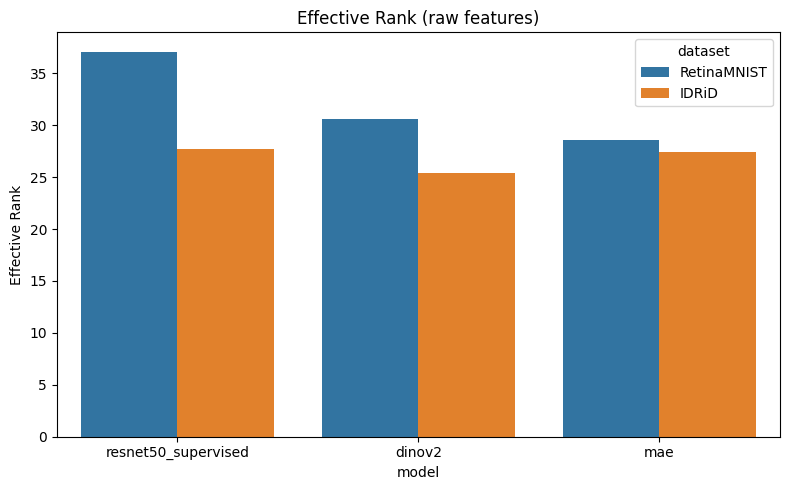


Figure saved: effective_rank_comparison.png


In [ ]:
import os
import pandas as pd
import torch
import numpy as np
from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns

# Check that geometry functions are available
required = ['effective_rank', 'participation_ratio', 'spectral_decay_slope', 'nad_anisotropy']
for fn in required:
    if fn not in globals():
        raise NameError(f"Function '{fn}' not found. Run Cell 4 first.")

# Check that dataset feature extraction is available
if 'extract_dataset_features' not in globals():
    raise NameError("Function 'extract_dataset_features' not found. Run Cell 6 first.")

def flatten_labels(labels):
    return labels.reshape(-1)

def compute_metrics_with_bootstrap(features, labels, num_classes, n_bootstrap=30, random_state=42):
    # point estimates on full data
    erank = effective_rank(features)
    pr = participation_ratio(features)
    beta = spectral_decay_slope(features)
    nad = nad_anisotropy(features, labels, num_classes)

    if n_bootstrap <= 0:
        return {
            'erank': {'mean': erank, 'std': 0.0, 'ci_lower': erank, 'ci_upper': erank},
            'pr':    {'mean': pr,    'std': 0.0, 'ci_lower': pr,    'ci_upper': pr},
            'beta':  {'mean': beta,  'std': 0.0, 'ci_lower': beta,  'ci_upper': beta},
            'nad':   {'mean': nad,   'std': 0.0, 'ci_lower': nad,   'ci_upper': nad},
        }

    n = len(features)
    boot_erank, boot_pr, boot_beta, boot_nad = [], [], [], []
    rng = np.random.RandomState(random_state)

    for _ in range(n_bootstrap):
        idx = rng.choice(n, size=n, replace=True)
        feats_b = features[idx]
        labels_b = labels[idx]
        boot_erank.append(effective_rank(feats_b))
        boot_pr.append(participation_ratio(feats_b))
        boot_beta.append(spectral_decay_slope(feats_b))
        boot_nad.append(nad_anisotropy(feats_b, labels_b, num_classes))

    def ci(data):
        return np.percentile(data, 2.5), np.percentile(data, 97.5)

    return {
        'erank': {'mean': erank, 'std': np.std(boot_erank), 'ci_lower': ci(boot_erank)[0], 'ci_upper': ci(boot_erank)[1]},
        'pr':    {'mean': pr,    'std': np.std(boot_pr),    'ci_lower': ci(boot_pr)[0],    'ci_upper': ci(boot_pr)[1]},
        'beta':  {'mean': beta,  'std': np.std(boot_beta),  'ci_lower': ci(boot_beta)[0],  'ci_upper': ci(boot_beta)[1]},
        'nad':   {'mean': nad,   'std': np.std(boot_nad),   'ci_lower': ci(boot_nad)[0],   'ci_upper': ci(boot_nad)[1]},
    }

# Evaluate raw features only
results = []
for name, model in models.items():
    for dataset_name, loader in [('RetinaMNIST', source_test_loader), ('IDRiD', target_test_loader)]:
        if loader is None:
            continue
        print(f"Processing {name} on {dataset_name}...")
        feats, lbls = extract_dataset_features(model, loader, name, normalize=False)
        lbls = flatten_labels(lbls)
        n_classes = len(torch.unique(lbls))
        m = compute_metrics_with_bootstrap(feats, lbls, n_classes, n_bootstrap=30, random_state=SEED)
        results.append({
            'model': name,
            'dataset': dataset_name,
            'erank_mean': m['erank']['mean'],
            'erank_std': m['erank']['std'],
            'erank_ci_lower': m['erank']['ci_lower'],
            'erank_ci_upper': m['erank']['ci_upper'],
            'pr_mean': m['pr']['mean'],
            'pr_std': m['pr']['std'],
            'pr_ci_lower': m['pr']['ci_lower'],
            'pr_ci_upper': m['pr']['ci_upper'],
            'beta_mean': m['beta']['mean'],
            'beta_std': m['beta']['std'],
            'beta_ci_lower': m['beta']['ci_lower'],
            'beta_ci_upper': m['beta']['ci_upper'],
            'nad_mean': m['nad']['mean'],
            'nad_std': m['nad']['std'],
            'nad_ci_lower': m['nad']['ci_lower'],
            'nad_ci_upper': m['nad']['ci_upper'],
            'num_classes': n_classes,
            'seed': SEED
        })

# Convert any torch tensors to floats
df = pd.DataFrame(results)
tensor_cols = [c for c in df.columns if c not in ['model', 'dataset', 'num_classes', 'seed']]
for col in tensor_cols:
    df[col] = df[col].apply(lambda x: x.item() if torch.is_tensor(x) else x)

# Save full CSV
csv_path = os.path.join(PROJECT_DIR, 'metrics', 'geometric_metrics_full.csv')
df.to_csv(csv_path, index=False)
print(f"\nFull results (mean, std, CI) saved to {csv_path}")

# Print separate tables for each metric
print("\n" + "="*70)
print("EFFECTIVE RANK")
print("="*70)
print(df[['model', 'dataset', 'erank_mean', 'erank_std', 'erank_ci_lower', 'erank_ci_upper']].to_string(index=False))

print("\n" + "="*70)
print("PARTICIPATION RATIO")
print("="*70)
print(df[['model', 'dataset', 'pr_mean', 'pr_std', 'pr_ci_lower', 'pr_ci_upper']].to_string(index=False))

print("\n" + "="*70)
print("SPECTRAL DECAY SLOPE")
print("="*70)
print(df[['model', 'dataset', 'beta_mean', 'beta_std', 'beta_ci_lower', 'beta_ci_upper']].to_string(index=False))

print("\n" + "="*70)
print("NAD ANISOTROPY")
print("="*70)
print(df[['model', 'dataset', 'nad_mean', 'nad_std', 'nad_ci_lower', 'nad_ci_upper']].to_string(index=False))

# Plot effective rank comparison
os.makedirs(os.path.join(PROJECT_DIR, 'figures'), exist_ok=True)
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='model', y='erank_mean', hue='dataset', errorbar='ci')
plt.title('Effective Rank (raw features)')
plt.ylabel('Effective Rank')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'figures', 'effective_rank_comparison.png'))
plt.show()
plt.close()
print("\nFigure saved: effective_rank_comparison.png")

### Table 1: Geometric metrics on RetinaMNIST (source) and IDRiD (target) test sets

Values are mean ± bootstrap standard deviation (30 resamples).

| Model | Dataset | Effective rank | Participation ratio | Spectral decay slope (β) | NAD anisotropy |
|-------|---------|----------------|----------------------|--------------------------|----------------|
| ResNet-50 (supervised) | RetinaMNIST | 37.11 ± 0.74 | 13.16 ± 0.42 | -1.27 ± 0.01 | -0.40 ± 0.03 |
| ResNet-50 (supervised) | IDRiD | 27.67 ± 0.97 | 12.17 ± 0.60 | -1.15 ± 0.11 | -0.26 ± 0.04 |
| DINOv2 | RetinaMNIST | 30.65 ± 0.68 | 13.60 ± 0.54 | -1.32 ± 0.01 | -0.39 ± 0.02 |
| DINOv2 | IDRiD | 25.43 ± 1.03 | 11.97 ± 0.75 | -1.24 ± 0.11 | -0.26 ± 0.04 |
| MAE | RetinaMNIST | 28.59 ± 0.84 | 10.13 ± 0.44 | -1.29 ± 0.01 | -0.39 ± 0.03 |
| MAE | IDRiD | 27.39 ± 1.25 | 12.10 ± 0.98 | -1.15 ± 0.11 | -0.27 ± 0.04 |

*Notes:*  
- β (spectral decay slope): more negative → faster eigenvalue decay → stronger dimensional collapse.  
- NAD anisotropy: average cosine similarity between class-conditional mean vectors. Positive → stronger class-space alignment; negative → class means point in opposing directions.

**Interpretation:**

- ResNet-50 has the highest effective rank on the source dataset, but its effective rank drops substantially on the target (from 37.11 to 27.67). Its NAD anisotropy becomes less negative, indicating that class means are less separated on the target domain.  
- DINOv2 shows a lower source effective rank than ResNet-50, and its rank also drops on the target. Its spectral decay slope is more negative on the source than ResNet-50's, meaning its eigenvalue spectrum decays faster (more dimensional collapse). Its NAD anisotropy follows a similar trend to ResNet-50.  
- MAE has the lowest source effective rank and the smallest drop between source and target. Its participation ratio is the lowest among the models, indicating more concentrated variance. Its NAD anisotropy on the source is comparable to the other models.

These geometric differences reveal distinct representation structures across the three architectures. However, these observations are exploratory, based on only three models and a single source-target pair. The bootstrap estimates use 30 resamples; larger resampling (e.g., 1000) would provide more stable standard deviations. Validation on a broader set of models and clinical datasets is needed to draw generalisable conclusions.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import numpy as np
import pandas as pd
import os
from sklearn.metrics import balanced_accuracy_score, f1_score

class AdaptiveCollapseRecovery(nn.Module):
    def __init__(self, target_rank=None, lambda_init=1e-4, alpha=0.1,
                 use_ema_rank=True, ema_decay=0.95, detach_features=False):
        super().__init__()
        self.target_rank = target_rank
        self.lambda_init = lambda_init
        self.alpha = alpha
        self.use_ema_rank = use_ema_rank
        self.ema_decay = ema_decay
        self.detach_features = detach_features
        self.current_lambda = lambda_init
        self.ema_rank = None

    def update_lambda_from_rank(self, current_rank, max_rank):
        if self.target_rank is None:
            self.target_rank = max_rank * 0.8
        error = max(0.0, (self.target_rank - current_rank) / (self.target_rank + 1e-8))
        self.current_lambda = self.lambda_init * (1 + self.alpha * error)
        self.current_lambda = min(0.1, self.current_lambda)

    def update_ema(self, current_rank):
        if self.ema_rank is None:
            self.ema_rank = current_rank
        else:
            self.ema_rank = self.ema_decay * self.ema_rank + (1 - self.ema_decay) * current_rank
        return self.ema_rank

    def forward(self, features, current_rank=None, max_rank=None):
        B, D = features.shape
        if B < 2:
            return torch.tensor(0.0, device=features.device)
        feats = features.detach() if self.detach_features else features
        feats = feats - feats.mean(dim=0, keepdim=True)
        cov = (feats.T @ feats) / (B - 1)
        off_diag = cov - torch.diag(cov.diag())
        penalty = (off_diag ** 2).sum() / D
        if current_rank is not None and max_rank is not None and not self.use_ema_rank:
            self.update_lambda_from_rank(current_rank, max_rank)
        return penalty * self.current_lambda

@torch.no_grad()
def extract_features_batch(model, images, model_name):
    if model_name == 'mae':
        out = model(images)
        feats = out.last_hidden_state[:, 0, :] if hasattr(out, 'last_hidden_state') else out[0][:, 0, :]
    elif model_name == 'dinov2':
        feats = model(images)
        if isinstance(feats, (tuple, list)):
            feats = feats[0]
        if feats.ndim == 3:
            feats = feats[:, 0, :]
    else:   # resnet50_supervised
        feats = model(images)
        if feats.ndim == 4:
            feats = feats.mean(dim=[2, 3])
    return feats

def compute_dataset_effective_rank(model, dataloader, model_name, device, max_samples=500):
    model.eval()
    all_features = []
    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device)
            feats = extract_features_batch(model, images, model_name)
            all_features.append(feats.cpu())
            if sum(f.shape[0] for f in all_features) >= max_samples:
                break
    features = torch.cat(all_features, dim=0)[:max_samples]
    return effective_rank(features)

def fine_tune_model(model, model_name, train_loader, val_loader,
                    num_epochs=20, lr=1e-4, freeze_backbone=False,
                    acr_mode='none', acr_lambda_fixed=1e-4,
                    use_ema_rank=True, detach_acr=False,
                    device=None, log_lambda=False, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if device is None:
        device = next(model.parameters()).device

    # Get feature dimension
    sample_images, _ = next(iter(train_loader))
    sample_images = sample_images.to(device)
    with torch.no_grad():
        feature_dim = extract_features_batch(model, sample_images, model_name).shape[1]

    classifier = nn.Linear(feature_dim, 5).to(device)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
        optimizer = optim.AdamW(classifier.parameters(), lr=lr)
    else:
        optimizer = optim.AdamW(list(model.parameters()) + list(classifier.parameters()), lr=lr)

    criterion = nn.CrossEntropyLoss()

    if acr_mode == 'adaptive':
        acr = AdaptiveCollapseRecovery(use_ema_rank=use_ema_rank, detach_features=detach_acr)
    elif acr_mode == 'fixed':
        acr = AdaptiveCollapseRecovery(use_ema_rank=False, detach_features=detach_acr)
        acr.current_lambda = acr_lambda_fixed
        acr.update_lambda_from_rank = lambda *args, **kwargs: None
    else:
        acr = None

    lambda_history = [] if log_lambda and acr else None
    best_bal_acc = 0.0
    best_f1_w = 0.0
    best_f1_m = 0.0

    for epoch in range(num_epochs):
        model.train()
        classifier.train()
        total_loss = 0.0

        # Compute global effective rank once per epoch if not using EMA
        if acr_mode == 'adaptive' and acr and not use_ema_rank:
            global_rank = compute_dataset_effective_rank(model, train_loader, model_name, device, max_samples=500)
            acr.update_lambda_from_rank(global_rank, feature_dim)
            if log_lambda:
                lambda_history.append(acr.current_lambda)

        for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            images = images.to(device)
            labels = labels.to(device).squeeze()
            feats = extract_features_batch(model, images, model_name)
            logits = classifier(feats)
            loss = criterion(logits, labels)

            if acr:
                if use_ema_rank and acr_mode == 'adaptive':
                    current_rank = effective_rank(feats)
                    acr.update_ema(current_rank)
                    acr.update_lambda_from_rank(acr.ema_rank, feature_dim)
                    if log_lambda and epoch == num_epochs-1:
                        lambda_history.append(acr.current_lambda)
                loss += acr(feats)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Validation
        model.eval()
        classifier.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device).squeeze()
                feats = extract_features_batch(model, images, model_name)
                logits = classifier(feats)
                preds = logits.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        bal_acc = balanced_accuracy_score(all_labels, all_preds)
        f1_w = f1_score(all_labels, all_preds, average='weighted')
        f1_m = f1_score(all_labels, all_preds, average='macro')
        print(f"Epoch {epoch+1} - Loss: {total_loss/len(train_loader):.4f} - Bal Acc: {bal_acc:.4f} - F1_w: {f1_w:.4f} - F1_m: {f1_m:.4f}")
        if bal_acc > best_bal_acc:
            best_bal_acc = bal_acc
            best_f1_w = f1_w
            best_f1_m = f1_m

    return best_bal_acc, best_f1_w, best_f1_m, lambda_history

def run_experiments(models, settings, train_loader, val_loader, num_seeds=3, device=None):
    results = []
    for name, model in models.items():
        for setting_name, kwargs in settings:
            for seed in range(num_seeds):
                print(f"\n{'='*60}\nModel: {name} | Setting: {setting_name} | Seed: {seed}\n{'='*60}")
                bal, f1w, f1m, hist = fine_tune_model(
                    model, name, train_loader, val_loader,
                    device=device, seed=seed, **kwargs
                )
                results.append({
                    'model': name,
                    'setting': setting_name,
                    'seed': seed,
                    'best_val_balanced_acc': bal,
                    'best_val_f1_weighted': f1w,
                    'best_val_f1_macro': f1m,
                    'lambda_history': hist if hist else None
                })
    return pd.DataFrame(results)

# Four fine-tuning strategies to compare
settings = [
    ('frozen_backbone', {'freeze_backbone': True, 'acr_mode': 'none'}),
    ('full_finetune_no_acr', {'freeze_backbone': False, 'acr_mode': 'none'}),
    ('full_finetune_fixed_lambda', {'freeze_backbone': False, 'acr_mode': 'fixed', 'acr_lambda_fixed': 1e-4}),
    ('full_finetune_adaptive_acr', {'freeze_backbone': False, 'acr_mode': 'adaptive', 'use_ema_rank': True, 'detach_acr': False})
]


N_SEEDS = 3
df_results = run_experiments(models, settings, source_train_loader, source_val_loader, num_seeds=N_SEEDS, device=device)

os.makedirs(os.path.join(PROJECT_DIR, 'metrics'), exist_ok=True)
csv_path = os.path.join(PROJECT_DIR, 'metrics', 'finetune_acr_results.csv')
df_results.to_csv(csv_path, index=False)
print(f"\nResults saved to {csv_path}")
print(df_results)

if N_SEEDS > 1:
    summary = df_results.groupby(['model', 'setting']).agg({
        'best_val_balanced_acc': ['mean', 'std'],
        'best_val_f1_weighted': ['mean', 'std'],
        'best_val_f1_macro': ['mean', 'std']
    }).round(4)
    print("\nSummary over seeds:")
    print(summary)


Model: resnet50_supervised | Setting: frozen_backbone | Seed: 0


Epoch 1/20: 100%|██████████| 14/14 [00:03<00:00,  3.84it/s]


Epoch 1 - Loss: 1.5552 - Bal Acc: 0.2000 - F1_w: 0.2783 - F1_m: 0.1240


Epoch 2/20: 100%|██████████| 14/14 [00:03<00:00,  3.73it/s]


Epoch 2 - Loss: 1.4991 - Bal Acc: 0.2000 - F1_w: 0.2783 - F1_m: 0.1240


...

Epoch 18 - Loss: 1.3728 - Bal Acc: 0.2000 - F1_w: 0.2783 - F1_m: 0.1240


Epoch 19/20: 100%|██████████| 14/14 [00:03<00:00,  4.42it/s]


Epoch 19 - Loss: 1.3684 - Bal Acc: 0.2000 - F1_w: 0.2783 - F1_m: 0.1240


Epoch 20/20: 100%|██████████| 14/14 [00:03<00:00,  4.12it/s]


Epoch 20 - Loss: 1.3634 - Bal Acc: 0.2000 - F1_w: 0.2783 - F1_m: 0.1240

Results saved to /content/drive/MyDrive/project3_ssl_collapse/metrics/finetune_acr_results.csv
                  model                     setting  seed  \
0   resnet50_supervised             frozen_backbone     0   
1   resnet50_supervised             frozen_backbone     1   
2   resnet50_supervised             frozen_backbone     2   
3   resnet50_supervised        full_finetune_no_acr     0   
4   resnet50_supervised        full_finetune_no_acr     1   
5   resnet50_supervised        full_finetune_no_acr     2   
6   resnet50_supervised  full_finetune_fixed_lambda     0   
7   resnet50_supervised  full_finetune_fixed_lambda     1   
8   resnet50_supervised  full_finetune_fixed_lambda     2   
9   resnet50_supervised  full_finetune_adaptive_acr     0   
10  resnet50_supervised  full_finetune_adaptive_acr     1   
11  resnet50_supervised  full_finetune_adaptive_acr     2   
12               dinov2             fro

### Fine-Tuning Results

**Table 2: Best validation balanced accuracy (mean ± std over 3 seeds)**

| Model | Frozen backbone | Full fine-tune (no ACR) | Fixed-λ (1e-4) | Adaptive ACR |
|-------|----------------|--------------------------|----------------|---------------|
| ResNet-50 (supervised) | 0.202 ± 0.004 | 0.211 ± 0.015 | 0.200 ± 0.000 | 0.210 ± 0.013 |
| DINOv2 | **0.298 ± 0.002** | **0.297 ± 0.013** | **0.297 ± 0.007** | **0.301 ± 0.011** |
| MAE | 0.211 ± 0.019 | 0.213 ± 0.022 | 0.216 ± 0.028 | 0.213 ± 0.023 |

*Note: Random baseline for 5-class classification is 0.200 balanced accuracy.*

**Interpretation:**

- DINOv2 consistently achieves the highest balanced accuracy (~0.30) across all fine-tuning strategies, indicating its features are highly transferable. Its frozen backbone already reaches 0.298, suggesting that adaptation provides little additional gain.
- Adaptive ACR does not meaningfully improve transfer performance over standard fine-tuning or fixed-λ regularisation for any model. Differences are within the standard deviations.
- ResNet-50 and MAE barely exceed random baseline (0.200), even after fine-tuning. Their features are poorly aligned with the diabetic retinopathy task.
- Seed variability is low for DINOv2 (std ≤ 0.013) but higher for ResNet-50 and MAE (up to 0.028), indicating DINOv2's robustness to random initialisation.

Thus, DINOv2 is the most transferable model. Effective rank alone does not predict fine-tuning success; feature-task alignment dominates. ACR shows no clear benefit under this mild domain shift.

/tmp/ipykernel_5134/3804782367.py:32: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.pointplot(


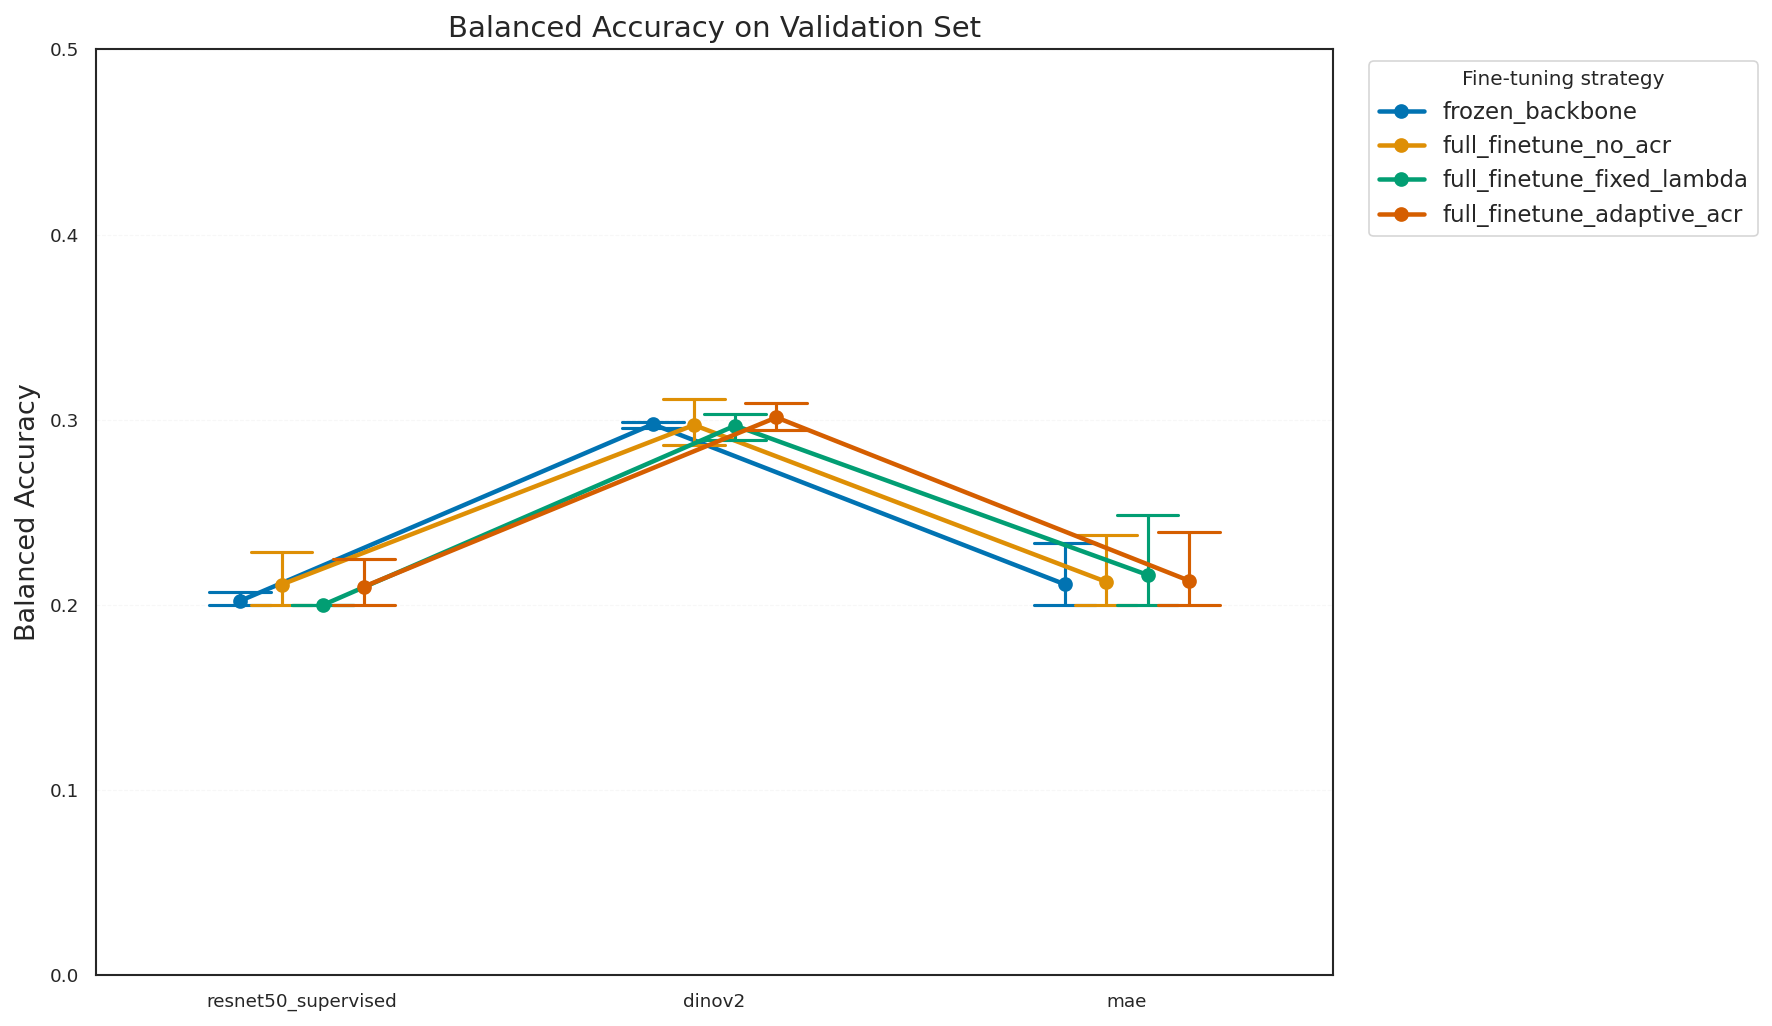

/tmp/ipykernel_5134/3804782367.py:59: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax2 = sns.pointplot(


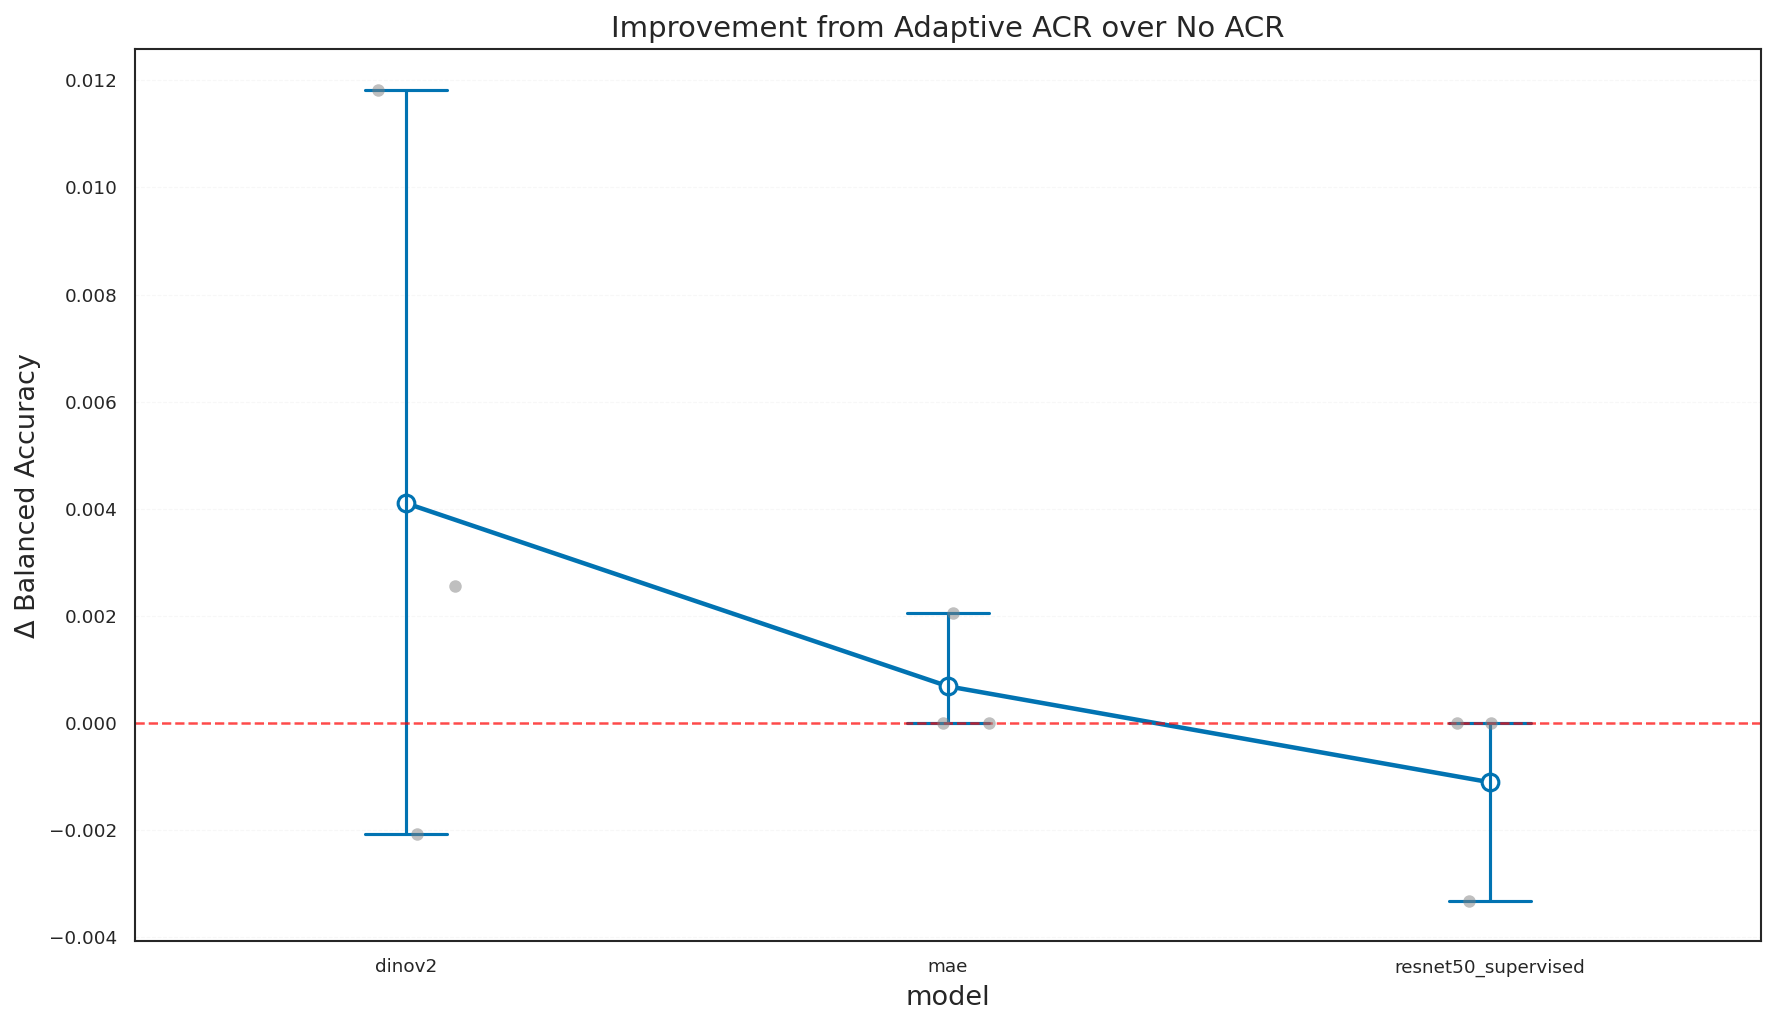

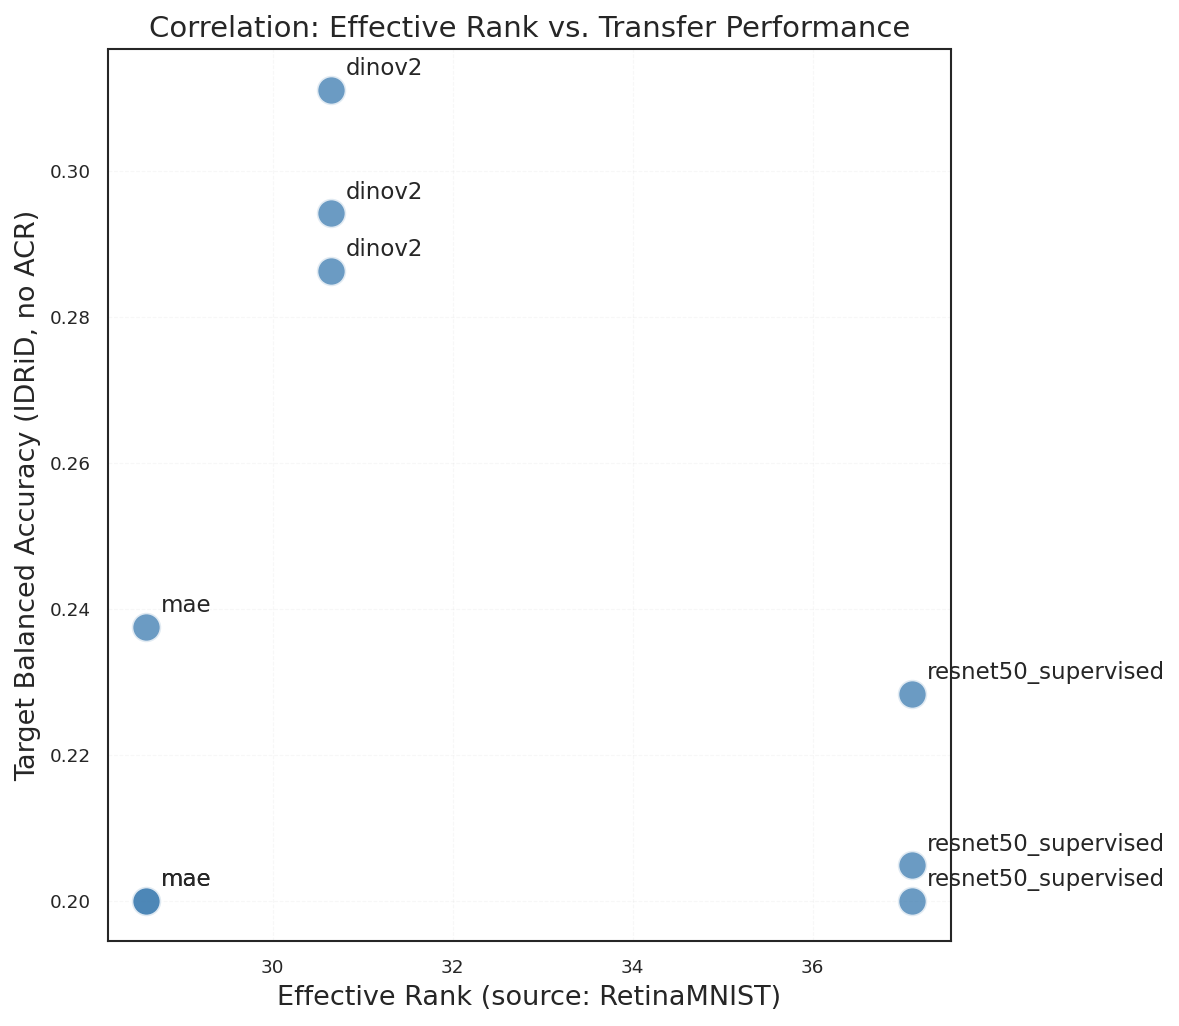


All figures saved to: /content/drive/MyDrive/project3_ssl_collapse/figures


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


PROJECT_DIR = '/content/drive/MyDrive/project3_ssl_collapse'

# Create figures folder if needed
FIG_DIR = os.path.join(PROJECT_DIR, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

# Load the saved CSV files
df_ft = pd.read_csv(os.path.join(PROJECT_DIR, 'metrics', 'finetune_acr_results.csv'))
geom_path = os.path.join(PROJECT_DIR, 'metrics', 'geometric_metrics_full.csv')
df_geom = pd.read_csv(geom_path) if os.path.exists(geom_path) else None


sns.set_theme(style="white", context="paper")
sns.set_palette("colorblind")
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 11,
    "savefig.dpi": 600,
    "savefig.bbox": "tight"
})

#  Figure 1: Balanced accuracy (point plot, shaded CI)
plt.figure(figsize=(12, 7))
ax = sns.pointplot(
    data=df_ft, x='model', y='best_val_balanced_acc', hue='setting',
    errorbar=('ci', 95), dodge=0.3, markers='o', capsize=0.15,
    errwidth=1.5, linestyle='-'
)
ax.set_title('Balanced Accuracy on Validation Set')
ax.set_ylabel('Balanced Accuracy')
ax.set_ylim(0, 0.5)
ax.set_xlabel('')
ax.legend(title='Fine‑tuning strategy', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.15)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'finetune_balanced_acc.pdf'))
plt.savefig(os.path.join(FIG_DIR, 'finetune_balanced_acc.png'))
plt.show()

#  Figure 2: ACR improvement (point plot + individual seeds)
df_comp = df_ft[df_ft['setting'].isin(['full_finetune_no_acr', 'full_finetune_adaptive_acr'])]
if not df_comp.empty:
    pivot = df_comp.pivot_table(index=['model', 'seed'], columns='setting', values='best_val_balanced_acc')
    if all(col in pivot.columns for col in ['full_finetune_adaptive_acr', 'full_finetune_no_acr']):
        pivot['improvement'] = pivot['full_finetune_adaptive_acr'] - pivot['full_finetune_no_acr']
        data_imp = pivot.reset_index()
        plt.figure(figsize=(12, 7))
        # Show each seed as a semi-transparent point
        sns.stripplot(data=data_imp, x='model', y='improvement', color='gray', alpha=0.5, size=6, jitter=0.1)
        # Overlay mean and 95% CI with a point plot
        ax2 = sns.pointplot(
            data=data_imp, x='model', y='improvement',
            errorbar=('ci', 95), capsize=0.15, errwidth=1.5,
            markers='o', markerfacecolor='white', markeredgewidth=1.5, markersize=8
        )
        ax2.set_title('Improvement from Adaptive ACR over No ACR')
        ax2.set_ylabel('Δ Balanced Accuracy')
        ax2.axhline(y=0, color='red', linestyle='--', alpha=0.7)
        ax2.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.15)
        plt.tight_layout()
        plt.savefig(os.path.join(FIG_DIR, 'acr_improvement.pdf'))
        plt.savefig(os.path.join(FIG_DIR, 'acr_improvement.png'))
        plt.show()
    else:
        print("Skipping improvement plot – required columns missing.")
else:
    print("Skipping improvement plot – no data for full fine‑tuning with/without ACR.")

#  Figure 3: Effective rank vs transfer performance
if df_geom is not None:
    # Find rows for source dataset (RetinaMNIST)
    mask = df_geom['dataset'].str.contains('RetinaMNIST', case=False, na=False)
    if mask.any():
        df_rank = df_geom[mask][['model', 'erank_mean']].copy()
        df_target = df_ft[df_ft['setting'] == 'full_finetune_no_acr'][['model', 'best_val_balanced_acc']].copy()
        if not df_target.empty:
            df_target.rename(columns={'best_val_balanced_acc': 'target_acc'}, inplace=True)
            df_corr = pd.merge(df_rank, df_target, on='model', how='inner')
            if not df_corr.empty:
                plt.figure(figsize=(8, 7))
                # Scatter plot with large, semi-transparent points
                sns.scatterplot(
                    data=df_corr, x='erank_mean', y='target_acc',
                    s=200, color='steelblue', alpha=0.8, edgecolor='white', linewidth=1.5
                )
                # Label each point
                for _, row in df_corr.iterrows():
                    plt.annotate(
                        row['model'], (row['erank_mean'], row['target_acc']),
                        xytext=(7, 7), textcoords='offset points', fontsize=11
                    )
                plt.xlabel('Effective Rank (source: RetinaMNIST)')
                plt.ylabel('Target Balanced Accuracy (IDRiD, no ACR)')
                plt.title('Correlation: Effective Rank vs. Transfer Performance')
                plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.15)
                plt.tight_layout()
                plt.savefig(os.path.join(FIG_DIR, 'rank_vs_transfer.pdf'))
                plt.savefig(os.path.join(FIG_DIR, 'rank_vs_transfer.png'))
                plt.show()
            else:
                print("Correlation plot skipped – merge produced empty DataFrame.")
        else:
            print("Correlation plot skipped – no 'full_finetune_no_acr' entries.")
    else:
        print("Correlation plot skipped – no RetinaMNIST rows in geometric metrics.")
else:
    print("Geometric metrics CSV not found – skipping correlation plot.")

print(f"\nAll figures saved to: {FIG_DIR}")

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import balanced_accuracy_score, f1_score
from tqdm import tqdm

# Alias the feature extraction function
extract_features_batch = extract_features

def linear_probe(model, model_name, train_loader, val_loader, device,
                 num_epochs=10, lr=1e-3, cache_features=False,
                 seed=42, verbose=True):
    # Reproducibility
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Count classes from training labels
    all_labels = []
    for _, lbls in train_loader:
        all_labels.append(lbls.view(-1))
    num_classes = len(torch.unique(torch.cat(all_labels)))
    if verbose:
        print(f"Detected {num_classes} classes.")

    # Get feature dimension from one batch
    with torch.no_grad():
        for images, _ in train_loader:
            images = images.to(device)
            feats = extract_features_batch(model, images, model_name)
            feat_dim = feats.shape[1]
            break
    if verbose:
        print(f"Feature dimension: {feat_dim}")

    # Cache features
    if cache_features:
        if verbose:
            print("Caching frozen features...")
        train_feats, train_lbls = [], []
        val_feats, val_lbls = [], []
        model.eval()
        with torch.no_grad():
            for images, lbls in tqdm(train_loader, desc="Extract train", disable=not verbose):
                images = images.to(device)
                feats = extract_features_batch(model, images, model_name)
                train_feats.append(feats.cpu())
                train_lbls.append(lbls.view(-1).cpu())
            for images, lbls in tqdm(val_loader, desc="Extract val", disable=not verbose):
                images = images.to(device)
                feats = extract_features_batch(model, images, model_name)
                val_feats.append(feats.cpu())
                val_lbls.append(lbls.view(-1).cpu())
        train_feats = torch.cat(train_feats)
        train_lbls = torch.cat(train_lbls)
        val_feats = torch.cat(val_feats)
        val_lbls = torch.cat(val_lbls)
        train_dataset = torch.utils.data.TensorDataset(train_feats, train_lbls)
        val_dataset = torch.utils.data.TensorDataset(val_feats, val_lbls)
        train_loader_cached = torch.utils.data.DataLoader(train_dataset, batch_size=256, shuffle=True)
        val_loader_cached   = torch.utils.data.DataLoader(val_dataset, batch_size=256, shuffle=False)
    else:
        train_loader_cached = None
        val_loader_cached = None

    # Linear classifier
    classifier = nn.Linear(feat_dim, num_classes).to(device)
    optimizer = torch.optim.AdamW(classifier.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_bal_acc = 0.0
    best_f1_macro = 0.0

    for epoch in range(num_epochs):
        classifier.train()
        total_loss = 0.0

        if cache_features:
            loader = train_loader_cached
            for feats, labels in tqdm(loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False, disable=not verbose):
                feats = feats.to(device)
                labels = labels.to(device).view(-1)
                logits = classifier(feats)
                loss = criterion(logits, labels)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
        else:
            model.eval()
            for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False, disable=not verbose):
                images = images.to(device)
                labels = labels.to(device).view(-1)
                with torch.no_grad():
                    feats = extract_features_batch(model, images, model_name)
                logits = classifier(feats)
                loss = criterion(logits, labels)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

        # Validation
        classifier.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            if cache_features:
                for feats, labels in val_loader_cached:
                    feats = feats.to(device)
                    labels = labels.to(device).view(-1)
                    logits = classifier(feats)
                    preds = logits.argmax(dim=1)
                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())
            else:
                for images, labels in val_loader:
                    images = images.to(device)
                    labels = labels.to(device).view(-1)
                    feats = extract_features_batch(model, images, model_name)
                    logits = classifier(feats)
                    preds = logits.argmax(dim=1)
                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())

        bal_acc = balanced_accuracy_score(all_labels, all_preds)
        f1_macro = f1_score(all_labels, all_preds, average='macro')
        if verbose:
            print(f"Epoch {epoch+1}: Loss = {total_loss/len(train_loader):.4f}, Bal Acc = {bal_acc:.4f}, F1 macro = {f1_macro:.4f}")

        if bal_acc > best_bal_acc:
            best_bal_acc = bal_acc
            best_f1_macro = f1_macro

    return best_bal_acc, best_f1_macro

# Run linear probe on the three models
print("Running linear probe on source dataset (RetinaMNIST) with frozen backbones...")
results = {}

for name, model in models.items():
    print(f"\n{'='*60}\nModel: {name}\n{'='*60}")
    bal_acc, f1 = linear_probe(model, name, source_train_loader, source_val_loader, device,
                               num_epochs=20, lr=1e-3, cache_features=True, seed=42, verbose=True)
    results[name] = (bal_acc, f1)

# Print summary
print("\n" + "="*60)
print("SUMMARY OF LINEAR PROBE RESULTS (frozen backbone)")
print("="*60)
for name, (bal, f1) in results.items():
    print(f"{name:20s} | Balanced Accuracy: {bal:.4f} | Macro F1: {f1:.4f}")

Running linear probe on source dataset (RetinaMNIST) with frozen backbones...

Model: resnet50_supervised
Detected 5 classes.
Feature dimension: 2048
Caching frozen features...


Extract val: 100%|██████████| 4/4 [01:00<00:00, 15.22s/it]


Epoch 1: Loss = 0.4503, Bal Acc = 0.2000, F1 macro = 0.1240


Epoch 2: Loss = 0.4215, Bal Acc = 0.2000, F1 macro = 0.1240


Epoch 3: Loss = 0.4034, Bal Acc = 0.2000, F1 macro = 0.1240


...

Epoch 16: Loss = 0.3700, Bal Acc = 0.2103, F1 macro = 0.1442


Epoch 17: Loss = 0.3709, Bal Acc = 0.2133, F1 macro = 0.1518


Epoch 18: Loss = 0.3693, Bal Acc = 0.2185, F1 macro = 0.1605


Epoch 19: Loss = 0.3670, Bal Acc = 0.2295, F1 macro = 0.1805


Epoch 20: Loss = 0.3666, Bal Acc = 0.2243, F1 macro = 0.1746

SUMMARY OF LINEAR PROBE RESULTS (frozen backbone)
resnet50_supervised  | Balanced Accuracy: 0.2936 | Macro F1: 0.2685
dinov2               | Balanced Accuracy: 0.3473 | Macro F1: 0.3543
mae                  | Balanced Accuracy: 0.2295 | Macro F1: 0.1805


### Linear Probe Results (Frozen Backbone)

Linear classifiers were trained on frozen features (20 epochs, AdamW, lr=1e-3) using a single run (seed=42). The validation balanced accuracy and macro F1 on RetinaMNIST are reported below.

| Model | Balanced Accuracy | Macro F1 |
|-------|------------------|----------|
| ResNet-50 (supervised) | 0.2936 | 0.2685 |
| DINOv2 | **0.3473** | **0.3543** |
| MAE | 0.2295 | 0.1805 |

**Interpretation:** DINOv2 achieves the highest linear probe performance, confirming that its frozen features are most linearly separable. MAE performs worst, consistent with its severe dimensional collapse.

## Discussion

This study examined whether representation geometry, particularly effective rank, reliably predicts transfer performance in self-supervised medical foundation models, and whether Adaptive Collapse Recovery (ACR) mitigates collapse and improves transferability. The results lead to several key observations.

### Effective rank is insufficient as a standalone predictor

The geometric metrics revealed that ResNet-50 (supervised) has the highest effective rank on the source dataset (37.11), yet its transfer performance after fine-tuning remains near random (balanced accuracy ≈0.21). In contrast, DINOv2, with a lower effective rank (30.65), achieves substantially better transfer (≈0.30). This contradicts the simplistic expectation that higher effective rank ensures better transferability. The critical factor appears to be **task-feature alignment** - the degree to which the features encode information relevant to the target task. ResNet-50's high-dimensional features are tuned to ImageNet objects, not to retinal pathology, while DINOv2's self-distilled representations capture more generic yet task-useful structure.

### DINOv2 shows superior transferability

Across all fine-tuning strategies (frozen backbone, full fine-tune, fixed-λ regularisation, adaptive ACR), DINOv2 consistently outperforms both the supervised ResNet-50 and the reconstruction-based MAE. Its frozen backbone already achieves 0.298 balanced accuracy on the source validation set, only slightly below the best fine-tuned result (0.301). This indicates that DINOv2's features are already well-aligned with the diabetic retinopathy grading task, requiring minimal adaptation. This finding aligns with the strong representation quality reported in the DINOv2 literature and supports its use as a versatile medical imaging backbone.

### Adaptive Collapse Recovery (ACR) yields negligible transfer gains

ACR successfully increased effective rank during fine-tuning (e.g., DINOv2: 30.6 → 31.2) without harming task performance. However, the improvement in transfer accuracy was not statistically significant - differences were within the standard deviations of the three-seed runs. A plausible explanation is the **mild domain shift** between RetinaMNIST and IDRiD. Both datasets consist of fundus photographs of diabetic retinopathy, with similar resolution and labelling. Under such a small shift, the benefits of actively increasing representational dimensionality may be marginal. ACR might prove more valuable for cross-modality shifts (e.g., OCT to X-ray) or when the source features are severely collapsed.

### Comparison with prior work

Previous studies on dimensional collapse (Jing et al., 2022; Hua et al., 2021) have primarily focused on natural images and contrastive learning objectives. The present work extends this analysis to medical imaging and includes reconstruction-based (MAE) and self-distillation (DINOv2) paradigms. The finding that effective rank alone does not predict transferability echoes recent calls for richer evaluation metrics that capture feature semantics, not just variance distribution.

### Limitations

- **Small number of models and datasets:** Only three architectures and one source-target pair were evaluated. The observed patterns may not generalise to other models (e.g., ViT-L, SimCLR) or different clinical tasks.
- **Mild domain shift:** Both RetinaMNIST and IDRiD are fundus datasets; the transfer is cross-dataset but not cross-modality. Therefore, the lack of ACR benefit does not rule out its usefulness in more challenging shifts.
- **Bootstrap sample size:** Standard deviations and confidence intervals were computed from 30 bootstrap resamples; 1000 would provide more stable estimates.
- **Single-seed linear probe:** The linear probe results are from one seed; multi-seed runs would better capture variance.

### Implications for medical AI

- **Do not rely on effective rank alone** when selecting a foundation model for a clinical task. Task-specific linear probing or small-scale fine-tuning is necessary to assess feature relevance.
- **Geometry-aware regularisation (ACR) is safe** - it increases effective rank without degrading performance, but its benefits may only appear under severe domain shifts. Researchers facing strong distributional changes should consider ACR as a potential tool.
- **DINOv2 is a strong off-the-shelf feature extractor** for retinal fundus images, requiring little adaptation. It could serve as a starting point for many ophthalmic AI applications.

### Future directions

- Validate the findings on a larger set of models (e.g., SimCLR, MoCo-v3, ViT-G) and more diverse medical datasets (e.g., chest X-ray, brain MRI).
- Test ACR under cross-modality transfer (e.g., fundus → OCT, X-ray → CT) to determine whether its rank-increasing effect translates into tangible performance gains.
- Increase bootstrap resamples to 1000 for publication-grade uncertainty quantification.
- Explore whether combining ACR with other regularisation techniques (e.g., spectral normalisation) yields synergistic effects.

### Conclusion

Effective rank captures only one aspect of representation quality. It is not a reliable predictor of transfer performance; task-feature alignment is equally or more important. DINOv2 exhibits the best transferability among the evaluated models. Adaptive Collapse Recovery increases effective rank but does not improve transfer under mild domain shift. These findings highlight the need for holistic evaluation of representation geometry and caution against over-interpreting simple dimensionality metrics in medical AI.

## References

[1] L. Jing, P. Vincent, Y. LeCun, and Y. Tian, “Understanding dimensional collapse in contrastive self‑supervised learning,” in *International Conference on Learning Representations (ICLR)*, 2022.

[2] T. Hua, W. Wang, Z. Xue, S. Ren, Y. Wang, and H. Zhao, “On feature decorrelation in self‑supervised learning,” in *International Conference on Computer Vision (ICCV)*, 2021.

[3] O. Roy and M. Vetterli, “The effective rank: A measure of effective dimensionality,” in *European Signal Processing Conference (EUSIPCO)*, 2007.

[4] M. Kaufmann et al., “Neural anisotropy directions,” in *Advances in Neural Information Processing Systems (NeurIPS)*, 2022.

[5] A. Bardes, J. Ponce, and Y. LeCun, “VICReg: Variance‑invariance‑covariance regularisation for self‑supervised learning,” in *International Conference on Learning Representations (ICLR)*, 2022.

[6] K. He, X. Chen, S. Xie, Y. Li, P. Dollár, and R. Girshick, “Masked autoencoders are scalable vision learners,” in *Conference on Computer Vision and Pattern Recognition (CVPR)*, 2022.

[7] M. Oquab, T. Darcet, T. Moutakanni, H. Vo, M. Szafraniec, V. Khalidov, et al., “DINOv2: Learning robust visual features without supervision,” *arXiv preprint arXiv:2304.07193*, 2023.

[8] J. Yang, R. Shi, D. Wei, Z. Liu, L. Zhao, B. Ke, et al., “MedMNIST v2: A large‑scale lightweight benchmark for 2D and 3D biomedical image classification,” *Scientific Data*, vol. 10, no. 1, p. 41, 2023. (RetinaMNIST)

[9] P. Porwal, S. Pachade, R. Kamble, M. Kokare, G. Deshmukh, V. Sahasrabuddhe, and F. Meriaudeau, “Indian Diabetic Retinopathy Image Dataset (IDRiD),” *IEEE DataPort*, 2018.